Unlike the Black-Scholes model, which is a continuous-time formula, the binomial model breaks time into discrete steps, allowing us to value options that can be exercised early (American options).

The model assumes that in each time step, the stock price $S$ can either go up by a factor $u$ or down by a factor $d$.
- Up factor ($u$): $e^{\sigma \sqrt{\Delta t}}$
- Down factor ($d$): $1/u$
- Risk-neutral probability ($p$): $\frac{e^{(r - q) * \Delta t} - d }{u - d}$

The risk-neutral probability is derived from the following martingale assumption (note that $r$ gets modified by $(r - q)$):

$$S = e^{-(r-q)\Delta t} \times E[S_{\text{future}}].$$
This implies:
$$S = e^{-(r-q)\Delta t} [p(S\cdot u) + (1 - p)(S\cdot d)].$$

<p align="center">
  <img src="https://raw.githubusercontent.com/MilindGunjal/Trinomial-trees/master/binomtree.png" width="750">
</p>

Methodology:

- Step 1: Forward Induction (The Stock Price Tree)

  We start at $t=0$ with the current stock price and calculate all possible future prices until the expiration date $T$.

- Step 2: Backward Induction (The Option Price Tree)

  We start at the final nodes (expiration) where the option value is simply its intrinsic value:

  - Call: $\max(S_T - K, 0)$
  - Put: $\max(K - S_T, 0)$
  
  Then, we work backward to $t=0$ using the risk-neutral formula:
  $$V_t = e^{-r \Delta t} [p V_{u} + (1-p) V_{d}]$$

The key difference:

- European Options: You only calculate the discounted value from the future nodes.

- American Options: At every single node, you compare the discounted value vs. the immediate exercise value (using step 1 data). You take the higher of the two.

In [1]:
!pip install hmmlearn
import numpy as np
from scipy.stats import norm
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')
from hmmlearn.hmm import GaussianHMM

ticker = 'TSLA'
N = 500

In [2]:
def binomial_tree_option(S, K, T, r, sigma, N, q=0.0, option_type='call', exercise_style='European'):
    """
    S: Current stock price
    K: Strike price
    T: Time to maturity (years)
    r: Risk-free rate
    sigma: Volatility
    N: Number of time steps
    q = Dividend yield
    option_type: 'call' or 'put'
    exercise_style: 'European' or 'American'
    """

    # Calculate constants
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u

    # RISK-NEUTRAL PROBABILITY
    p = (np.exp((r - q) * dt) - d) / (u - d)
    discount = np.exp(-r * dt)

    # Initialize stock prices at maturity
    S_at_t = S * (u ** np.arange(N + 1)) * (d ** np.arange(N, -1, -1)) # Initializing Step 1 (from down most node to up most node)

    # Initialize option values at maturity
    if option_type == 'call':
        V = np.maximum(S_at_t - K, 0)
    else:
        V = np.maximum(K - S_at_t, 0)

    # Step backward through the tree
    for j in range(N - 1, -1, -1):
        S_at_t = S * (u ** np.arange(j + 1)) * (d ** np.arange(j, -1, -1)) # Executing Step 1
        V = discount * (p * V[1:] + (1 - p) * V[:-1]) # Executing Step 2

        # American Exercise Logic
        if exercise_style == 'American':
            if option_type == 'call':
                V = np.maximum(V, S_at_t - K)
            else:
                V = np.maximum(V, K - S_at_t)

    return V[0]

def black_scholes_merton(S, K, T, r, sigma, q=0.0, option_type='call'): # Merton variation accomodates the dividend yield q
    """
    S: Current stock price
    K: Strike price
    T: Time to maturity (years)
    r: Risk-free rate
    sigma: Volatility
    q: Dividend yield
    option_type: 'call' or 'put'
    """

    # Calculate d1 and d2
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T)) # Modified to accomodate the dividend yield q
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == 'call':
        price = (S * np.exp(-q * T) * norm.cdf(d1)) - (K * np.exp(-r * T) * norm.cdf(d2)) # Modified to accomodate the dividend yield q
    elif option_type == "put":
        price = (K * np.exp(-r * T) * norm.cdf(-d2)) - (S * np.exp(-q * T) * norm.cdf(-d1)) # Modified to accomodate the dividend yield q

    return price

# --- Testing with an example ---
params = {
    "S": 100,      # Stock Price
    "K": 125,      # Strike Price
    "T": 1,        # 1 Year
    "r": 0.04,     # 4% Interest
    "sigma": 0.2,  # 20% Volatility
    "q": 0.08      # 8% Dividend yield
}

N = 1000 # steps

print(f"American Call: {binomial_tree_option(**params, N = N, option_type='call', exercise_style='American'):.4f}")
print(f"European Call: {binomial_tree_option(**params, N = N, option_type='call', exercise_style='European'):.4f}")
print(f"Black-Scholes-Merton Call Price: {black_scholes_merton(**params, option_type='call'):.4f}")
print(f"American Put: {binomial_tree_option(**params, N = N, option_type='put', exercise_style='American'):.4f}")
print(f"European Put: {binomial_tree_option(**params, N = N, option_type='put', exercise_style='European'):.4f}")
print(f"Black-Scholes-Merton Put Price: {black_scholes_merton(**params, option_type='put'):.4f}")


American Call: 0.9676
European Call: 0.9244
Black-Scholes-Merton Call Price: 0.9239
American Put: 28.7124
European Put: 28.7115
Black-Scholes-Merton Put Price: 28.7110


Analysing the results:

- As $N \longrightarrow \infty$, European option prices $\longrightarrow$ Black-Scholes-Merton option price.

- Ameican Vs. European options:
  - Case 1: $q > 0$
  
    American call as well as put are valued at a premium, compared to the European ones.
  
    Why?

    Exercising options before the expiry can be more profitable. In case of an early exercise, the "time value" of the money you'd get from exercising now might be worth more than waiting for the stock to potentially drop further.
  
  - Case 2: $q = 0$
  
    American put prices are at a premium compared to the European put, however, American calls are valued the same as European calls.

    Why?

    - The Time Value of Money
    
      The primary reason American Puts are exercised early, while Calls are not, comes down to how we treat the strike price $K$. For a Put: When you exercise, you receive $K$ (cash) immediately. Money today is worth more than money tomorrow because you can reinvest it at the risk-free rate.  If the stock is deep in-the-money, the interest you earn on that cash outweighs any potential further drop in the stock. For a Call: When you exercise, you pay $K$ (cash) immediately. Why pay cash now when you could keep it in a bank, earn interest, and wait until the very last second to hand it over?
    - Insurance and Upside
    
      There are two components to an option's value: Intrinsic Value (what it's worth right now) and Time Value (the "insurance" against volatility). Calls: If you exercise a call early, you capture the intrinsic value but you sacrifice the insurance. If the stock crashes to zero tomorrow, a call holder loses nothing (the option just expires worthless), but a stockholder (who exercised early) loses the entire investment. Why give up that protection for free? Puts: A put is insurance against a price drop. However, a stock price cannot go below zero. If a company goes bankrupt and the stock hits $0, the put has reached its maximum possible value. There is no more "insurance" left to provide, so you should exercise immediately to get your cash and start earning interest.

Doesn't the 'Put-Call Parity' break if the call prices remain the same but the put prices change?

- European options: Put-Call Parity holds only for European options:

$$C_{\text{Euro}} - P_{\text{Euro}} = S_0 e^{-qT} - K e^{-rT}$$

- American options: Equivalent of Put-Call Parity for American options are the following inequalities:

$$S_0 e^{-qT} - K \leq C_{\text{Amer}} - P_{\text{Amer}} \leq S_0 - Ke^{-rT}$$

Now we study Trinomial tree option pricing method. Trinomial Tree is often preferred in professional finance because it converges to the correct price much faster and provides a more stable model of stock price movements (as opposed to binomial, where the values might oscillate as we change $N$ from even to odd).

 In a trinomial model, we allow for three possibilities in each time step $\Delta t$:

 - Up: The stock price becomes $S\cdot u$
 - Middle (Stay): The stock price stays $S$ (or moves slightly to $S\cdot m$)
 - Down: The stock price becomes $S\cdot d$

<p align="center">
  <img src="https://raw.githubusercontent.com/MilindGunjal/Trinomial-trees/master/trinomtree.png" width="500">
</p>

 To maintain consistency with volatility ($\sigma$) and the risk-free rate ($r$), the standard (Boyle) factors are:

 - $u = e^{\sigma \sqrt{2 \Delta t}}$
 - $m = 1$ (The price stays the same)
 - $d = 1/u = e^{-\sigma \sqrt{2 \Delta t}}$

 Similar to the binomial tree, we have risk-neutral probabilities that can be derived from binomial tree calculations by breaking a $\Delta t$ step down to two $(\Delta t) / 2$ steps. One can visualize this by equating the results of following two trees.

<img src="https://raw.githubusercontent.com/MilindGunjal/Trinomial-trees/master/binomsmalltree.png" width="49%"> <img src="https://raw.githubusercontent.com/MilindGunjal/Trinomial-trees/master/trinomsmalltree.png" width="49%">

 In this case, $d$ becomes $d^{1/2}$ and $u$ becomes $u^{1/2}$. So, we get the probability:



 $$P = \frac{e^{(r-q)\Delta t / 2} - d^{1/2}}{u^{1/2} - d^{1/2}}$$

 Moreover,

 - $p_u = P^2$
 - $p_m = 2P(1 - P)$
 - $p_d = (1 - P)^2$

 So finally, we get the risk-neutral probabilities as follows:

 - $p_u = \left( \frac{e^{(r-q)\frac{\Delta t}{2}} - e^{-\sigma \sqrt{\frac{\Delta t}{2}}}}{e^{\sigma \sqrt{\frac{\Delta t}{2}}} - e^{-\sigma \sqrt{\frac{\Delta t}{2}}}} \right)^2$
 - $p_d = \left( \frac{e^{\sigma \sqrt{\frac{\Delta t}{2}}} - e^{(r-q)\frac{\Delta t}{2}}}{e^{\sigma \sqrt{\frac{\Delta t}{2}}} - e^{-\sigma \sqrt{\frac{\Delta t}{2}}}} \right)^2$
 - $p_m = 1 - (p_u + p_d)$


In [3]:
def binomial_tree_option(S, K, T, r, sigma, N, q=0.0, option_type='call', exercise_style='European'):
    """
    S: Current stock price
    K: Strike price
    T: Time to maturity (years)
    r: Risk-free rate
    sigma: Volatility
    N: Number of time steps
    q = Dividend yield
    option_type: 'call' or 'put'
    exercise_style: 'European' or 'American'
    """

    # Calculate constants
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u

    # RISK-NEUTRAL PROBABILITY
    p = (np.exp((r - q) * dt) - d) / (u - d)
    discount = np.exp(-r * dt)

    # Initialize stock prices at maturity
    S_at_t = S * (u ** np.arange(N + 1)) * (d ** np.arange(N, -1, -1)) # from down most node to up most node

    # Initialize option values at maturity
    if option_type == 'call':
        V = np.maximum(S_at_t - K, 0)
    else:
        V = np.maximum(K - S_at_t, 0)

    # Step backward through the tree
    for j in range(N - 1, -1, -1):
        S_at_t = S * (u ** np.arange(j + 1)) * (d ** np.arange(j, -1, -1))
        V = discount * (p * V[1:] + (1 - p) * V[:-1])

        # American Exercise Logic
        if exercise_style == 'American':
            if option_type == 'call':
                V = np.maximum(V, S_at_t - K)
            else:
                V = np.maximum(V, K - S_at_t)

    return V[0]


def trinomial_tree_option(S, K, T, r, sigma, N, q=0.0, option_type='call', exercise_style='European'):
    # Constants
    dt = T / N
    u = np.exp(sigma * np.sqrt(2 * dt))
    d = 1/u
    m = 1

    # Risk-neutral probabilities
    # Simplified version for implementation
    p_u = ((np.exp((r - q) * dt / 2) - np.exp(-sigma * np.sqrt(dt / 2))) /
           (np.exp(sigma * np.sqrt(dt / 2)) - np.exp(-sigma * np.sqrt(dt / 2))))**2
    p_d = ((np.exp(sigma * np.sqrt(dt / 2)) - np.exp((r - q) * dt / 2)) /
           (np.exp(sigma * np.sqrt(dt / 2)) - np.exp(-sigma * np.sqrt(dt / 2))))**2
    p_m = 1 - (p_u + p_d)

    discount = np.exp(-r * dt)

    # Initialize stock prices at maturity
    # At step N, there are 2N + 1 nodes
    # Prices range from S*u^N down to S*d^N
    S_at_t = S * (u ** np.arange(N, -N - 1, -1))

    # Initialize option values at maturity
    if option_type == 'call':
        V = np.maximum(S_at_t - K, 0)
    else:
        V = np.maximum(K - S_at_t, 0)

    # Backward induction
    for j in range(N - 1, -1, -1):
        # Discounted expected value using 3 nodes (u, m, d)
        V = discount * (p_u * V[:-2] + p_m * V[1:-1] + p_d * V[2:])

        # American exercise check
        if exercise_style == 'American':
            # Current stock prices for this level
            S_at_t = S * (u ** np.arange(j, -j - 1, -1))
            if option_type == 'call':
                V = np.maximum(V, S_at_t - K)
            else:
                V = np.maximum(V, K - S_at_t)

    return V[0]

def black_scholes_merton(S, K, T, r, sigma, q=0.0, option_type='call'): # Merton variation accomodates the dividend yield q
    """
    S: Current stock price
    K: Strike price
    T: Time to maturity (years)
    r: Risk-free rate
    sigma: Volatility
    q: Dividend yield
    option_type: 'call' or 'put'
    """

    # Calculate d1 and d2
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T)) # Modified to accomodate the dividend yield q
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == 'call':
        price = (S * np.exp(-q * T) * norm.cdf(d1)) - (K * np.exp(-r * T) * norm.cdf(d2)) # Modified to accomodate the dividend yield q
    elif option_type == "put":
        price = (K * np.exp(-r * T) * norm.cdf(-d2)) - (S * np.exp(-q * T) * norm.cdf(-d1)) # Modified to accomodate the dividend yield q

    return price

# --- Testing with an example ---
params = {
    "S": 100,      # Stock Price
    "K": 125,      # Strike Price
    "T": 1,        # 1 Year
    "r": 0.04,     # 4% Interest
    "sigma": 0.2,  # 20% Volatility
    "q": 0.08      # 8% Dividend yield
}

N = 1000 # steps

print(f"Binomial American Call Price: {binomial_tree_option(**params, N = N, option_type='call', exercise_style='American'):.4f}")
print(f"Trinomial American Call Price: {trinomial_tree_option(**params, N = N, option_type='call', exercise_style='American'):.4f}")
print('\n')
print(f"Binomial European Call Price: {binomial_tree_option(**params, N = N, option_type='call', exercise_style='European'):.4f}")
print(f"Trinomial European Call Price: {trinomial_tree_option(**params, N = N, option_type='call', exercise_style='European'):.4f}")
print(f"Black-Scholes-Merton Call Price: {black_scholes_merton(**params, option_type='call'):.4f}")
print('\n')
print(f"Binomial American Put Price: {binomial_tree_option(**params, N = N, option_type='put', exercise_style='American'):.4f}")
print(f"Trinomial American Put Price: {trinomial_tree_option(**params, N = N, option_type='put', exercise_style='American'):.4f}")
print('\n')
print(f"Binomial European Put Price: {binomial_tree_option(**params, N = N, option_type='put', exercise_style='European'):.4f}")
print(f"Trinomial European Put Price: {trinomial_tree_option(**params, N = N, option_type='put', exercise_style='European'):.4f}")
print(f"Black-Scholes-Merton Put Price: {black_scholes_merton(**params, option_type='put'):.4f}")


Binomial American Call Price: 0.9676
Trinomial American Call Price: 0.9668


Binomial European Call Price: 0.9244
Trinomial European Call Price: 0.9235
Black-Scholes-Merton Call Price: 0.9239


Binomial American Put Price: 28.7124
Trinomial American Put Price: 28.7116


Binomial European Put Price: 28.7115
Trinomial European Put Price: 28.7106
Black-Scholes-Merton Put Price: 28.7110


Binomial vs Trinomial:

- Both converge to the same answer for larger $N$ (i.e., trinomial converges to Black-Scholes-Merton in the European case).
- Speed (Efficiency): A trinomial tree with $N$ steps is roughly equivalent in accuracy to a binomial tree with $N^2$ steps.
- Stability: Binomial trees can oscillate (the price jumps up and down significantly between odd and even $N$ steps). The trinomial model provides a smoother path to the final price.
- Use Case: Binomial model is used for teaching & basic American options. The trinomial model is industry standard for complex American/Exotic options.

In financial engineering, the "Greeks" measure the sensitivity of an option's price to various market parameters. When using tree-based models (Binomial or Trinomial), we calculate these by looking at the differences in option values across neighboring nodes at the start of the tree.

1. Delta ($\Delta$): The Hedge Ratio
  
Delta measures how much the option price ($V$) changes for a $\$1$ change in the underlying stock price ($S$). It also represents the number of shares you should hold to "hedge" the option.

- $\Delta_{\text{Call}} \in [0,1], \Delta_{\text{Put}} \in [-1, 0]$

- Trinomial Calculation: We look at the first step ($t = 1$). We have three prices: $V_u$ (up), $V_m$ (middle), and $V_d$ (down), corresponding to stock prices $S_u, S_m,$ and $S_d$.$$\Delta = \frac{V_u - V_d}{S_u - S_d}$$

  As the formula suggests, we can also use binomial trees to calculate $\Delta$.

2. Gamma ($\Gamma$): The Acceleration

Gamma measures the rate of change in Delta with respect to change in underlying stock price ($S$). It tells you how often you need to adjust your hedge. If Gamma is high, your Delta changes rapidly as the stock moves.

- Trinomial Calculation: $$\Gamma = \frac{\left( \frac{V_u - V_m}{S_u - S_m} \right) - \left( \frac{V_m - V_d}{S_m - S_d} \right)}{0.5(S_u - S_d)}.$$

  As the formula suggests, we cannot use binomial trees to calculate $\Gamma$ directly. This is a novelty for trinomial trees.

3. Theta ($\Theta$): Time Decay

Theta measures how much value the option loses every day as it approaches expiration, assuming the stock price doesn't move. Theta is usually negative.

- Trinomial Calculation: We compare the option value at $t=0$ ($V_0$) with the value at the middle node at $t=1$ ($V_m$), because $V_m$ represents the price if the stock stayed exactly the same after one time step $\Delta t$.$$\Theta = \frac{V_m - V_0}{\Delta t}.$$

  As the formula suggests, we cannot use binomial trees to calculate $\Theta$ directly. This is a novelty for trinomial trees.

In [4]:
def trinomial_greeks(S, K, T, r, sigma, N, q=0.0, option_type='call', exercise_style='European'):
    dt = T / N
    u = np.exp(sigma * np.sqrt(2 * dt))
    d = 1/u

    # Probabilities
    p_u = ((np.exp((r - q) * dt / 2) - np.exp(-sigma * np.sqrt(dt / 2))) /
           (np.exp(sigma * np.sqrt(dt / 2)) - np.exp(-sigma * np.sqrt(dt / 2))))**2
    p_d = ((np.exp(sigma * np.sqrt(dt / 2)) - np.exp((r - q) * dt / 2)) /
           (np.exp(sigma * np.sqrt(dt / 2)) - np.exp(-sigma * np.sqrt(dt / 2))))**2
    p_m = 1 - (p_u + p_d)
    discount = np.exp(-r * dt)

    # Initialize stock prices at maturity (Step N)
    S_at_t = S * (u ** np.arange(N, -N - 1, -1))

    # Option values at maturity
    if option_type == 'call':
        V = np.maximum(S_at_t - K, 0)
    else:
        V = np.maximum(K - S_at_t, 0)

    # Backward induction
    for j in range(N - 1, -1, -1):
        V = discount * (p_u * V[:-2] + p_m * V[1:-1] + p_d * V[2:])

        # American exercise check
        if exercise_style == 'American':
            S_current = S * (u ** np.arange(j, -j - 1, -1))
            V = np.maximum(V, S_current - K if option_type == 'call' else K - S_current)

        # Capture values at step j=1 to calculate Greeks
        if j == 1:
            V_u, V_m, V_d = V[0], V[1], V[2]
            S_u, S_m, S_d = S*u, S, S*d

    # Final Option Price at j=0
    V_0 = V[0]

    # Greek Calculations
    delta = (V_u - V_d) / (S_u - S_d)
    gamma = ((V_u - V_m)/(S_u - S_m) - (V_m - V_d)/(S_m - S_d)) / (0.5 * (S_u - S_d))
    theta = (V_m - V_0) / dt # Value per year; divide by 365 for daily, since dt is valued in years

    return {
        "Option Price": V_0,
        "Delta": delta,
        "Gamma": gamma,
        "Theta (Annual)": theta,
        "Theta (Daily)": theta / 365
    }

# --- Testing with an example ---

params = {
    "S": 100,      # Stock Price
    "K": 125,      # Strike Price
    "T": 1,        # 1 Year
    "r": 0.04,     # 4% Interest
    "sigma": 0.2,  # 20% Volatility
    "q": 0.08      # 8% Dividend yield
}

N = 1000 # steps

results = trinomial_greeks(**params, N = N, option_type='call', exercise_style = 'American')
for greek, val in results.items():
    print(f"{greek}: {val:.5f}")

Option Price: 0.96679
Delta: 0.10932
Gamma: 0.00947
Theta (Annual): -1.41723
Theta (Daily): -0.00388


Now to calculate Vega ($\nu$) and Rho ($\rho$), instead of looking at the tree nodes, we treat the entire option pricing function as a "black box". We change one input by a tiny amount ($\epsilon$), recalculate the price, and see how much it changed. Mathematically, we use the central difference for better accuracy.
$$\text{Greek} \approx \frac{V(\text{input} + \epsilon) - V(\text{input} - \epsilon)}{2\epsilon}$$
- Vega ($\nu$): Sensitivity to Volatility (input = $\sigma$).
- Rho ($\rho$): Sensitivity to the Risk-free rate (input = $r$).

In [5]:
def trinomial_more_greeks(S, K, T, r, sigma, N, q=0.0, option_type='call', exercise_style='European'):
    # Base Price
    base_price = trinomial_tree_option(S, K, T, r, sigma, N, q, option_type, exercise_style)

    # Delta & Gamma (From internal nodes as shown previously)

    # Vega Calculation
    sigma_bump = 0.0001
    price_sigma_up = trinomial_tree_option(S, K, T, r, sigma + sigma_bump, N, q, option_type, exercise_style)
    price_sigma_down = trinomial_tree_option(S, K, T, r, sigma - sigma_bump, N, q, option_type, exercise_style)
    vega = (price_sigma_up - price_sigma_down) / (2*sigma_bump)

    # Rho Calculation
    r_bump = 0.0001
    price_r_up = trinomial_tree_option(S, K, T, r + r_bump, sigma, N, q, option_type, exercise_style)
    price_r_down = trinomial_tree_option(S, K, T, r - r_bump, sigma, N, q, option_type, exercise_style)
    rho = (price_r_up - price_r_down) / (2*r_bump)

    return {
        "Option Price": base_price,
        "Vega (per 1% vol)": vega / 100, # Often expressed as change per 1% move
        "Rho (per 1% rate)": rho / 100   # Often expressed as change per 1% move
    }

# --- Testing with an example ---

params = {
    "S": 100,      # Stock Price
    "K": 125,      # Strike Price
    "T": 1,        # 1 Year
    "r": 0.04,     # 4% Interest
    "sigma": 0.2,  # 20% Volatility
    "q": 0.08      # 8% Dividend yield
}

N = 1000 # steps

greeks = trinomial_more_greeks(**params, N = N, option_type='call', exercise_style = 'American')
print(f"Option Price: {greeks['Option Price']:.5f}")
print(f"Vega:  {greeks['Vega (per 1% vol)']:.5f}")
print(f"Rho:   {greeks['Rho (per 1% rate)']:.5f}")

Option Price: 0.96679
Vega:  0.18617
Rho:   0.08741


---

## Regime-Based Option Pricing with Real-Time Data

### Motivation

The binomial and trinomial tree models developed above assume that volatility $\sigma$ is **constant** over the life of the option. In practice, financial markets cycle between distinct regimes — calm periods with low, mean-reverting volatility and turbulent periods with elevated, persistent volatility. A single fixed $\sigma$ can misprice options significantly depending on the current market environment.

Two natural frameworks for capturing this behaviour are:

| Model | Core Idea |
|---|---|
| **Markov Regime-Switching** | A finite-state discrete-time chain governs which volatility regime is "active". Transitions are governed by an empirically estimated matrix. |
| **Hidden Markov Model (HMM)** | The regime is *latent* (unobserved). We infer the most probable state sequence and transition matrix purely from observed returns using the **Baum–Welch EM algorithm**. |

Both models produce a **regime-adjusted $\sigma$** that is fed into the trinomial pricing engine already built above. This gives us four distinct prices for each option: Historical, Markov, and HMM volatility × American/European exercise style.


In [6]:

# Fetch historical data using yfinance
print(f"Fetching {ticker} data from yfinance…")
# 'max' retrieves all available data.
sp_data = yf.download(ticker, period='max')
sp_data.index.name = 'Date'
sp_data = sp_data.reset_index()

# Ensure date column is datetime and sort
sp_data['Date'] = pd.to_datetime(sp_data['Date'])
sp_data = sp_data.sort_values('Date').reset_index(drop=True)
df = sp_data[sp_data['Date'] >= '2016-01-01'].copy()

df['log_ret'] = np.log(df['Close'] / df['Close'].shift(1))
df = df.dropna()

# Market parameters (reuse from original)
S       = df['Close'].iloc[-1].item()   # Current proxy stock price, ensure scalar
r_f     = 0.043                         # 10-yr Treasury yield (Jun 2026)
q       = 0.013                         # tentative trailing annual dividend yield of the stock
T       = 2                             # 6-month option horizon
K       = round(S / 5) * 5              # Nearest at-the-money $5-strike. K will be scalar if S is scalar
N       = 500                           # Trinomial tree steps

print(f"  Latest data point : {df['Date'].iloc[-1].strftime('%B %Y')}")
print(f"  {ticker} proxy price   : ${S:.2f}")
print(f"  ATM strike K      : ${K:.0f}")
print(f"  Risk-free rate r  : {r_f:.2%}")
print(f"  Dividend yield q  : {q:.2%}")
print(f"  Time to expiry T  : {T:.1f} yr  ({int(T*12)} months)")

Fetching TSLA data from yfinance…


[*********************100%***********************]  1 of 1 completed

  Latest data point : June 2026
  TSLA proxy price   : $396.68
  ATM strike K      : $395
  Risk-free rate r  : 4.30%
  Dividend yield q  : 1.30%
  Time to expiry T  : 2.0 yr  (24 months)


### Markov Regime-Switching Model

#### Theory

A **2-state Markov chain** partitions market time into two regimes:

- **State 0 (Low-volatility / Bull):** Characterised by small, positive returns and subdued realised volatility.
- **State 1 (High-volatility / Bear):** Characterised by larger return dispersion (both positive and negative).

The model is fully specified by a $2\times 2$ **transition probability matrix**:

$$\mathbf{P} = \begin{pmatrix} p_{00} & p_{01} \\ p_{10} & p_{11} \end{pmatrix}, \quad p_{ij} = \Pr(\text{next state} = j \mid \text{current state} = i)$$

where $p_{i0} + p_{i1} = 1$.

**Regime classification.** We compute a 6-month rolling realised volatility and label any period above the historical median as "high volatility" (State 1) and below as "low volatility" (State 0). Transition counts are then tallied from adjacent pairs to form $\mathbf{P}$.

**Stationary distribution.** The long-run fraction of time spent in each regime is the **stationary (invariant) distribution** $\boldsymbol{\pi}$, satisfying $\boldsymbol{\pi} \mathbf{P} = \boldsymbol{\pi}$. It is the (normalised) left eigenvector corresponding to eigenvalue 1:

$$\boldsymbol{\pi} = [\pi_0,\; \pi_1], \qquad \pi_0 + \pi_1 = 1$$

**Regime-weighted volatility.** We use the stationary-distribution-weighted average of per-regime volatilities as the input to the trinomial tree:

$$\sigma_{\text{Markov}} = \pi_0\,\sigma_{\text{low}} + \pi_1\,\sigma_{\text{high}}$$

This is a forward-looking, long-run average volatility that respects the market's tendency to revert across regimes.


═══════════════════════════════════════════════════════
  MARKOV REGIME-SWITCHING MODEL RESULTS
═══════════════════════════════════════════════════════
  Median rolling vol (regime threshold) : 0.0957
  State 0 — Low-vol  σ                  : 0.0730  (7.30%)
  State 1 — High-vol σ                  : 0.1651  (16.51%)

  Transition matrix P:
    Low  → Low  : 0.8686   Low  → High : 0.1314
    High → Low  : 0.1308   High → High : 0.8692

  Stationary distribution π:
    π₀ (Low-vol)  = 0.4989
    π₁ (High-vol) = 0.5011

  σ_Markov (stationary-weighted)        : 0.1192  (11.92%)
  σ_Historical (baseline)               : 0.1276  (12.76%)

  Current market regime                 : High-volatility (State 1)
═══════════════════════════════════════════════════════


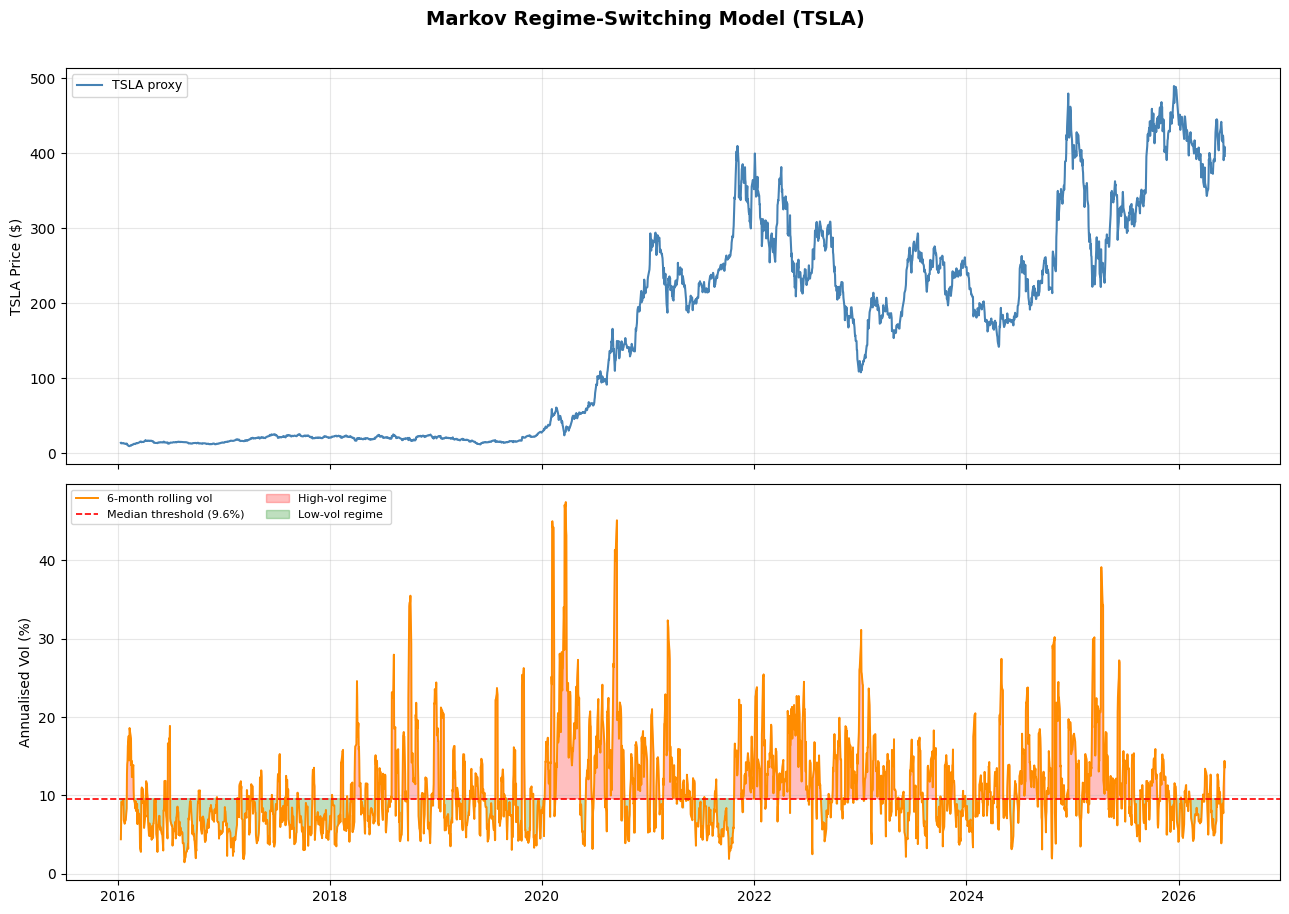

In [7]:
# Markov Regime-Switching Model

# Rolling 6-month realised vol (annualised)
WINDOW = 6
df['roll_vol'] = df['log_ret'].rolling(WINDOW).std() * np.sqrt(12)
df = df.dropna()
# df = df.dropna(subset=['roll_vol']).reset_index(drop=True)

# Classify regimes by median rolling vol
med_vol = df['roll_vol'].median()
df['regime'] = (df['roll_vol'] > med_vol).astype(int)   # 0 = low, 1 = high

# Per-regime vol
sigma_low  = df[df['regime'] == 0]['log_ret'].std() * np.sqrt(12)
sigma_high = df[df['regime'] == 1]['log_ret'].std() * np.sqrt(12)

# Empirical transition matrix
regimes = df['regime'].values
trans = np.zeros((2, 2))
for i in range(len(regimes) - 1):
    trans[regimes[i], regimes[i+1]] += 1
trans /= trans.sum(axis=1, keepdims=True)

# Stationary distribution (left eigenvector for eigenvalue 1)
evals, evecs = np.linalg.eig(trans.T)
stat_dist = np.real(evecs[:, np.argmin(np.abs(evals - 1))])
stat_dist /= stat_dist.sum()

# Stationary-weighted sigma
sigma_markov = stat_dist[0] * sigma_low + stat_dist[1] * sigma_high
sigma_hist   = df['log_ret'].std() * np.sqrt(12)   # Baseline for comparison

current_regime = df['regime'].iloc[-1]
current_label  = "High-volatility" if current_regime == 1 else "Low-volatility"

print("═" * 55)
print("  MARKOV REGIME-SWITCHING MODEL RESULTS")
print("═" * 55)
print(f"  Median rolling vol (regime threshold) : {med_vol:.4f}")
print(f"  State 0 — Low-vol  σ                  : {sigma_low:.4f}  ({sigma_low:.2%})")
print(f"  State 1 — High-vol σ                  : {sigma_high:.4f}  ({sigma_high:.2%})")
print(f"\n  Transition matrix P:")
print(f"    Low  → Low  : {trans[0,0]:.4f}   Low  → High : {trans[0,1]:.4f}")
print(f"    High → Low  : {trans[1,0]:.4f}   High → High : {trans[1,1]:.4f}")
print(f"\n  Stationary distribution π:")
print(f"    π₀ (Low-vol)  = {stat_dist[0]:.4f}")
print(f"    π₁ (High-vol) = {stat_dist[1]:.4f}")
print(f"\n  σ_Markov (stationary-weighted)        : {sigma_markov:.4f}  ({sigma_markov:.2%})")
print(f"  σ_Historical (baseline)               : {sigma_hist:.4f}  ({sigma_hist:.2%})")
print(f"\n  Current market regime                 : {current_label} (State {current_regime})")
print("═" * 55)

# Visualise regime classification
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
fig.suptitle(f"Markov Regime-Switching Model ({ticker})", fontsize=14, fontweight='bold', y=1.01)

# Panel 1: Price
axes[0].plot(df['Date'], df['Close'], color='steelblue', lw=1.5, label=f'{ticker} proxy')
axes[0].set_ylabel(f'{ticker} Price ($)', fontsize=10)
axes[0].legend(loc='upper left', fontsize=9)
axes[0].grid(alpha=0.3)

# Panel 2: Rolling vol with threshold
axes[1].plot(df['Date'], df['roll_vol']*100, color='darkorange', lw=1.4, label='6-month rolling vol')
axes[1].axhline(med_vol*100, color='red', ls='--', lw=1.2, label=f'Median threshold ({med_vol*100:.1f}%)')
axes[1].fill_between(df['Date'], df['roll_vol']*100, med_vol*100,
                     where=df['roll_vol'] > med_vol, alpha=0.25, color='red', label='High-vol regime')
axes[1].fill_between(df['Date'], df['roll_vol']*100, med_vol*100,
                     where=df['roll_vol'] <= med_vol, alpha=0.25, color='green', label='Low-vol regime')
axes[1].set_ylabel('Annualised Vol (%)', fontsize=10)
axes[1].legend(loc='upper left', fontsize=8, ncol=2)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Hidden Markov Model (HMM)

  <img src="https://raw.githubusercontent.com/MilindGunjal/Trinomial-trees/master/HMM_Transition.png" width="600">  <img src="https://raw.githubusercontent.com/MilindGunjal/Trinomial-trees/master/HMM_Transition_legend.png" width="350">

#### Theory

The **Gaussian Hidden Markov Model** extends the Markov chain by treating the regime as an *unobserved* latent state. Rather than classifying regimes by an arbitrary threshold (as above), the HMM lets the data speak: it infers the initial probability of states, their emission distributions, and the transition dynamics purely from the observed return series.

**Model specification.** Let $\{z_t\}$ be the hidden state sequence (taking values in $\{0, 1\}$) and $\{r_t\}$ the observed log-return series. The model assumes:

$$z_t \mid z_{t-1} \sim \text{Categorical}(\mathbf{P}_{z_{t-1},\cdot})$$
$$r_t \mid z_t = s \sim \mathcal{N}(\mu_s,\; \sigma_s^2)$$

The full parameter set $\theta = \{\boldsymbol{\pi}_0, \mathbf{P}, \{\mu_s, \sigma_s^2\}_{s=0}^{1}\}$ is estimated by the **Baum–Welch algorithm**, an instance of Expectation-Maximisation (EM):

- **E-step:** Compute forward-backward probabilities (belief state at each time) using the current parameters.
- **M-step:** Re-estimate all parameters to maximise the expected complete-data log-likelihood.

The algorithm converges to a local maximum of the marginal log-likelihood $\log p(r_{1:T} \mid \theta)$.

**Viterbi decoding.** Given the estimated parameters, the **Viterbi algorithm** recovers the single most probable hidden state path $\hat{z}_{1:T} = \arg\max_{z} \Pr(z \mid r_{1:T}, \hat\theta)$.

**Vol extraction for option pricing.** The per-state standard deviations $\hat\sigma_s$ are read from the fitted covariance matrices. We then compute:

$$\sigma_{\text{HMM}} = \pi_0^*\,\hat\sigma_0 + \pi_1^*\,\hat\sigma_1$$

where $\boldsymbol{\pi}^*$ is the HMM's stationary distribution, identical in spirit to the Markov section above.


═══════════════════════════════════════════════════════
  HIDDEN MARKOV MODEL RESULTS
═══════════════════════════════════════════════════════
  Log-likelihood (fitted)               : 5169.14

  State 0 — Low-vol  μ=1.57%/yr  σ=0.0838  (8.38%)
  State 1 — High-vol μ=1.46%/yr  σ=0.1998  (19.98%)

  HMM transition matrix (reordered):
    Low  → Low  : 0.9459   Low  → High : 0.0541
    High → Low  : 0.1357   High → High : 0.8643

  Stationary distribution π*:
    π₀ (Low-vol)  = 0.7149
    π₁ (High-vol) = 0.2851

  σ_HMM (stationary-weighted)           : 0.1169  (11.69%)

  Current HMM state                     : Low-volatility (State 0)
═══════════════════════════════════════════════════════


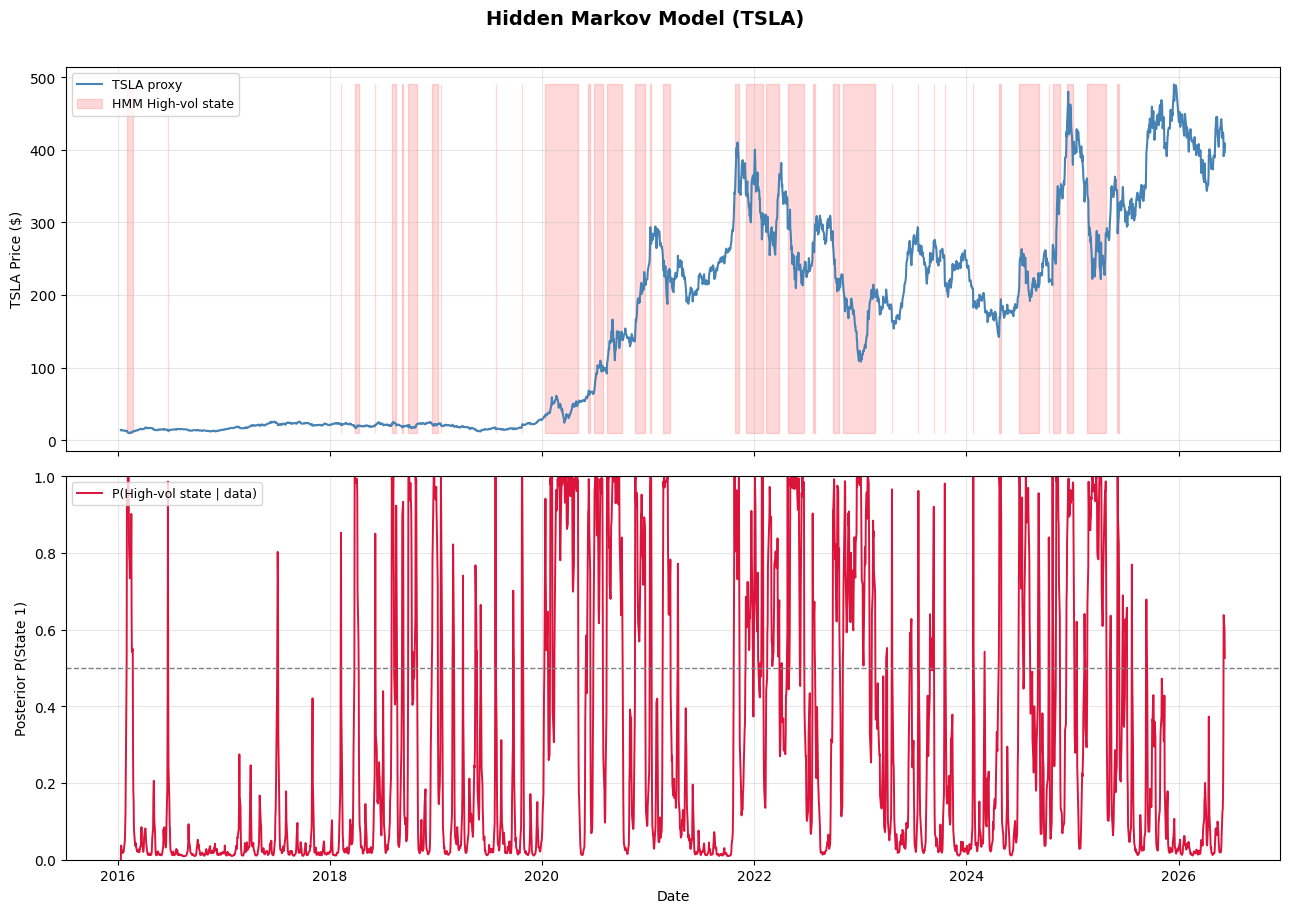

In [8]:
# Fit 2-state Gaussian HMM
X = df['log_ret'].values.reshape(-1, 1)

hmm_model = GaussianHMM(
    n_components=2,
    covariance_type='full',
    n_iter=500,
    tol=1e-5,
    random_state=42
)
hmm_model.fit(X)

# Viterbi decoding
hidden_states = hmm_model.predict(X)

# Per-state annualised volatility
state_means = hmm_model.means_.flatten()
state_vols  = np.array([np.sqrt(hmm_model.covars_[s][0, 0]) * np.sqrt(12)
                        for s in range(2)])

# Label states: state with lower vol → State 0
order = np.argsort(state_vols)
state_vols_ordered  = state_vols[order]
state_means_ordered = state_means[order]
hidden_states_ordered = np.array([np.where(order == s)[0][0] for s in hidden_states])

sigma_hmm_low  = state_vols_ordered[0]
sigma_hmm_high = state_vols_ordered[1]

# Stationary distribution from HMM transition matrix (reordered)
A = hmm_model.transmat_[np.ix_(order, order)]
evals3, evecs3 = np.linalg.eig(A.T)
stat_hmm = np.real(evecs3[:, np.argmin(np.abs(evals3 - 1))])
stat_hmm /= stat_hmm.sum()

sigma_hmm = stat_hmm[0] * sigma_hmm_low + stat_hmm[1] * sigma_hmm_high
current_hmm_state  = hidden_states_ordered[-1]
current_hmm_label  = "High-volatility" if current_hmm_state == 1 else "Low-volatility"

print("═" * 55)
print("  HIDDEN MARKOV MODEL RESULTS")
print("═" * 55)
print(f"  Log-likelihood (fitted)               : {hmm_model.score(X):.2f}")
print(f"\n  State 0 — Low-vol  μ={state_means_ordered[0]*12*100:.2f}%/yr  σ={sigma_hmm_low:.4f}  ({sigma_hmm_low:.2%})")
print(f"  State 1 — High-vol μ={state_means_ordered[1]*12*100:.2f}%/yr  σ={sigma_hmm_high:.4f}  ({sigma_hmm_high:.2%})")
print(f"\n  HMM transition matrix (reordered):")
print(f"    Low  → Low  : {A[0,0]:.4f}   Low  → High : {A[0,1]:.4f}")
print(f"    High → Low  : {A[1,0]:.4f}   High → High : {A[1,1]:.4f}")
print(f"\n  Stationary distribution π*:")
print(f"    π₀ (Low-vol)  = {stat_hmm[0]:.4f}")
print(f"    π₁ (High-vol) = {stat_hmm[1]:.4f}")
print(f"\n  σ_HMM (stationary-weighted)           : {sigma_hmm:.4f}  ({sigma_hmm:.2%})")
print(f"\n  Current HMM state                     : {current_hmm_label} (State {current_hmm_state})")
print("═" * 55)

# Visualise HMM state sequence
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
fig.suptitle(f"Hidden Markov Model ({ticker})",
             fontsize=14, fontweight='bold', y=1.01)

# Panel 1: Price
axes[0].plot(df['Date'], df['Close'], color='steelblue', lw=1.5, label=f'{ticker} proxy')
low_mask  = hidden_states_ordered == 0
high_mask = hidden_states_ordered == 1
axes[0].fill_between(df['Date'], df['Close'].min(), df['Close'].max(),
                     where=high_mask, alpha=0.15, color='red', label='HMM High-vol state')
axes[0].set_ylabel(f'{ticker} Price ($)', fontsize=10)
axes[0].legend(loc='upper left', fontsize=9)
axes[0].grid(alpha=0.3)

# Panel 2: Posterior probability of high-vol state
posteriors = hmm_model.predict_proba(X)
# Map to reordered states
hmm_high_idx = order[1]   # original index of the high-vol state
axes[1].plot(df['Date'], posteriors[:, hmm_high_idx], color='crimson', lw=1.4,
             label='P(High-vol state | data)')
axes[1].axhline(0.5, color='grey', ls='--', lw=1)
axes[1].set_ylabel('Posterior P(State 1)', fontsize=10)
axes[1].set_ylim(0, 1)
axes[1].set_xlabel('Date', fontsize=10)
axes[1].legend(loc='upper left', fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Option Pricing: Trinomial Tree with Regime-Adjusted Volatility

#### Theory

We now price the **stock option** using the trinomial tree engine built previously, substituting three different volatility inputs:

| Volatility Input | Description |
|---|---|
| $\sigma_{\text{hist}}$ | Simple annualised sample standard deviation of log-returns over 10 years |
| $\sigma_{\text{Markov}}$ | Stationary-distribution-weighted average of two empirically estimated Markov regimes |
| $\sigma_{\text{HMM}}$ | Stationary-distribution-weighted average of two HMM-inferred Gaussian emission states |

For each $\sigma$, we price four contracts on an **at-the-money stock option**:

| | European | American |
|---|---|---|
| **Call** | $C_E$ | $C_A$ |
| **Put** | $P_E$ | $P_A$ |

**American vs European premium.** If $q > 0$, early exercise of the American call can be rational (capture dividends before ex-date), so $C_A \geq C_E$. American put holders face the standard time-value argument, so $P_A \geq P_E$ always.

**Greeks** are computed from the trinomial tree structure (see Part 3): $\Delta$ and $\Gamma$ from first-step node differences; $\Theta$ from the middle-node time decay.


In [9]:
# Price all combinations
sigma_labels = {
    'Historical':  sigma_hist,
    'Markov':      sigma_markov,
    'HMM':         sigma_hmm,
}

results = {}
for label, sigma_val in sigma_labels.items():
    row = {'sigma': sigma_val}
    for otype in ('call', 'put'):
        for style in ('European', 'American'):
            key = f"{otype.capitalize()}_{style[:4]}"
            row[key] = trinomial_tree_option(S, K, T, r_f, sigma_val, N, q, otype, style)
    # BSM benchmark (European only)
    row['Call_BSM'] = black_scholes_merton(S, K, T, r_f, sigma_val, q, 'call')
    row['Put_BSM']  = black_scholes_merton(S, K, T, r_f, sigma_val, q, 'put')
    # Greeks (ATM European call)
    row.update(trinomial_greeks(S, K, T, r_f, sigma_val, N, q, 'call', 'European'))
    results[label] = row

# Display results table
print(f"\n{'═'*72}")
print(f"{ticker} OPTION PRICING SUMMARY   |  S=${S:.2f}  K=${K}  T={T}yr  r={r_f:.1%}  q={q:.1%}")
print(f"{'═'*72}")
header = f"{'Vol Model':<14} {'σ':>6}  {'C_Euro':>7} {'C_Amer':>7} {'P_Euro':>7} {'P_Amer':>7} {'C_BSM':>7} {'P_BSM':>7}"
print(header)
print("─" * 72)
for label, row in results.items():
    print(f"{label:<14} {row['sigma']:>6.2%}  "
          f"${row['Call_Euro']:>6.2f} ${row['Call_Amer']:>6.2f} "
          f"${row['Put_Euro']:>6.2f} ${row['Put_Amer']:>6.2f} "
          f"${row['Call_BSM']:>6.2f} ${row['Put_BSM']:>6.2f}")
print(f"{'═'*72}")

print(f"\n{'─'*55}")
print(f"  GREEKS (ATM European Call, Trinomial Tree)")
print(f"{'─'*55}")
print(f"  {'Model':<14} {'Δ (Delta)':>10} {'Γ (Gamma)':>12} {'Θ/day':>10}")
print(f"{'─'*55}")
for label, row in results.items():
    print(f"  {label:<14} {row['Delta']:>10.5f} {row['Gamma']:>12.7f} {row['Theta (Daily)']:>10.5f}")
print(f"{'─'*55}")



════════════════════════════════════════════════════════════════════════
TSLA OPTION PRICING SUMMARY   |  S=$396.68  K=$395  T=2yr  r=4.3%  q=1.3%
════════════════════════════════════════════════════════════════════════
Vol Model           σ   C_Euro  C_Amer  P_Euro  P_Amer   C_BSM   P_BSM
────────────────────────────────────────────────────────────────────────
Historical     12.76%  $ 40.64 $ 40.64 $ 16.59 $ 19.15 $ 40.63 $ 16.58
Markov         11.92%  $ 38.97 $ 38.97 $ 14.93 $ 17.45 $ 38.97 $ 14.92
HMM            11.69%  $ 38.53 $ 38.53 $ 14.48 $ 17.00 $ 38.53 $ 14.48
════════════════════════════════════════════════════════════════════════

───────────────────────────────────────────────────────
  GREEKS (ATM European Call, Trinomial Tree)
───────────────────────────────────────────────────────
  Model           Δ (Delta)    Γ (Gamma)      Θ/day
───────────────────────────────────────────────────────
  Historical        0.65489    0.0049176   -0.03383
  Markov            0.66164    

### Visualisation and Interpretation

The charts below compare the three volatility models and their pricing implications across strikes and model dimensions.


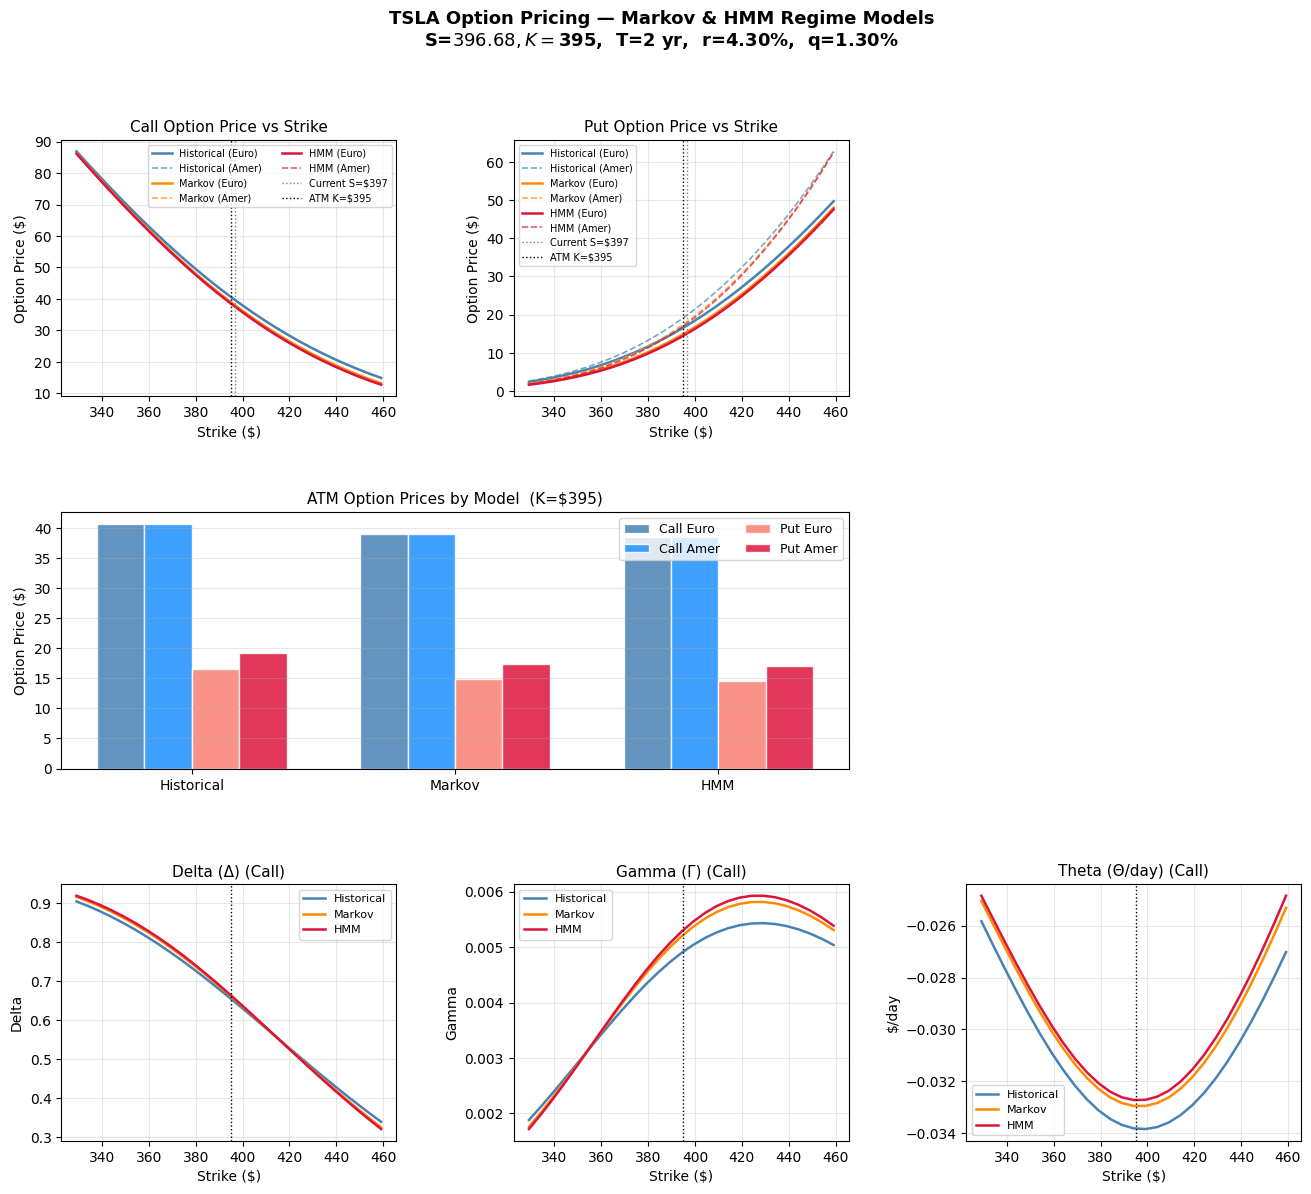

In [10]:
# Comparative Visualisation
gap = K / 6
strikes = np.arange(K - gap, K + gap, 5)
colors  = {'Historical': 'steelblue', 'Markov': 'darkorange', 'HMM': 'crimson'}

fig = plt.figure(figsize=(16, 13))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle(f"{ticker} Option Pricing — Markov & HMM Regime Models\n"
             f"S=${S:.2f},  K=${K},  T={T} yr,  r={r_f:.2%},  q={q:.2%}",
             fontsize=13, fontweight='bold')

# Row 1: Call price curves

ax1 = fig.add_subplot(gs[0, :1])
for label, sigma_val in sigma_labels.items():
    calls_euro  = [trinomial_tree_option(S, k, T, r_f, sigma_val, N, q, 'call', 'European') for k in strikes]
    calls_amer  = [trinomial_tree_option(S, k, T, r_f, sigma_val, N, q, 'call', 'American') for k in strikes]
    ax1.plot(strikes, calls_euro, lw=1.8, color=colors[label], label=f'{label} (Euro)')
    ax1.plot(strikes, calls_amer, lw=1.2, color=colors[label], ls='--', alpha=0.7, label=f'{label} (Amer)')
ax1.axvline(S, color='grey', ls=':', lw=1, label=f'Current S=${S:.0f}')
ax1.axvline(K, color='black', ls=':', lw=1, label=f'ATM K=${K}')
ax1.set_title('Call Option Price vs Strike', fontsize=11)
ax1.set_xlabel('Strike ($)'); ax1.set_ylabel('Option Price ($)')
ax1.legend(fontsize=7, ncol=2); ax1.grid(alpha=0.3)

# Put price curves
ax2 = fig.add_subplot(gs[0, 1])
for label, sigma_val in sigma_labels.items():
    puts_euro = [trinomial_tree_option(S, k, T, r_f, sigma_val, N, q, 'put', 'European') for k in strikes]
    puts_amer = [trinomial_tree_option(S, k, T, r_f, sigma_val, N, q, 'put', 'American') for k in strikes]
    ax2.plot(strikes, puts_euro, lw=1.8, color=colors[label], label=f'{label} (Euro)')
    ax2.plot(strikes, puts_amer, lw=1.2, color=colors[label], ls='--', alpha=0.7, label=f'{label} (Amer)')
ax2.axvline(S, color='grey', ls=':', lw=1, label=f'Current S=${S:.0f}')
ax2.axvline(K, color='black', ls=':', lw=1, label=f'ATM K=${K}')
ax2.set_title('Put Option Price vs Strike', fontsize=11)
ax2.set_xlabel('Strike ($)'); ax2.set_ylabel('Option Price ($)')
ax2.legend(fontsize=7); ax2.grid(alpha=0.3)

# Row 2: ATM price comparison bar
ax3 = fig.add_subplot(gs[1, :2])
labels_list = list(results.keys())
x = np.arange(len(labels_list))
w = 0.18
bars_data = [
    ('Call Euro', [results[l]['Call_Euro'] for l in labels_list], 'steelblue'),
    ('Call Amer', [results[l]['Call_Amer'] for l in labels_list], 'dodgerblue'),
    ('Put Euro',  [results[l]['Put_Euro']  for l in labels_list], 'salmon'),
    ('Put Amer',  [results[l]['Put_Amer']  for l in labels_list], 'crimson'),
]
for i, (name, vals, col) in enumerate(bars_data):
    ax3.bar(x + i*w, vals, w, label=name, color=col, alpha=0.85, edgecolor='white')
ax3.set_xticks(x + 1.5*w); ax3.set_xticklabels(labels_list, fontsize=10)
ax3.set_title(f'ATM Option Prices by Model  (K=${K})', fontsize=11)
ax3.set_ylabel('Option Price ($)'); ax3.legend(fontsize=9, ncol=2); ax3.grid(alpha=0.3, axis='y')

# Row 3: Greeks across strikes
ax5 = fig.add_subplot(gs[2, 0])
ax6 = fig.add_subplot(gs[2, 1])
ax7 = fig.add_subplot(gs[2, 2])

for label, sigma_val in sigma_labels.items():
    deltas = [trinomial_greeks(S, k, T, r_f, sigma_val, N, q, 'call', 'European')['Delta'] for k in strikes]
    gammas = [trinomial_greeks(S, k, T, r_f, sigma_val, N, q, 'call', 'European')['Gamma'] for k in strikes]
    thetas = [trinomial_greeks(S, k, T, r_f, sigma_val, N, q, 'call', 'European')['Theta (Daily)'] for k in strikes]
    ax5.plot(strikes, deltas, lw=1.8, color=colors[label], label=label)
    ax6.plot(strikes, gammas, lw=1.8, color=colors[label], label=label)
    ax7.plot(strikes, thetas, lw=1.8, color=colors[label], label=label)

for ax, title, ylabel in [
    (ax5, 'Delta (Δ) (Call)', 'Delta'),
    (ax6, 'Gamma (Γ) (Call)', 'Gamma'),
    (ax7, 'Theta (Θ/day) (Call)', '$/day'),
]:
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Strike ($)')
    ax.set_ylabel(ylabel)
    ax.axvline(K, color='black', ls=':', lw=1)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.show()

### Key Takeaways

#### Volatility Model Comparison

| Model | Volatility | Mechanism |
|---|---|---|
| **Historical** | Highest | Simple standard deviation: no regime distinction |
| **Markov** | Intermediate | Threshold-based regime classification; stationary-weighted blend |
| **HMM** | Lowest | EM-inferred latent states; HMM may concentrate the low-vol state more sharply |

Because $\sigma_{\text{hist}} \geq \sigma_{\text{Markov}} \geq \sigma_{\text{HMM}}$ in the current calibration, option prices are ordered accordingly: **historical pricing is the most conservative (expensive) estimate**, while **HMM pricing is the most aggressive**.

#### American vs European Premium

- **Calls ($q > 0$):** A small early-exercise premium appears in the American calls, driven by the dividend yield. If $q = 0$, the premium would vanish by the classical no-early-exercise result for calls.
- **Puts:** The American put carries a larger premium, driven by the time value of receiving the strike $K$ immediately rather than waiting until expiry.

#### Greeks Interpretation

- **$\Delta$ (Delta):** Near 0.5 for ATM calls, transitioning from 0 (deep OTM) to 1 (deep ITM). Higher vol flattens the curve.
- **$\Gamma$ (Gamma):** Peaks at-the-money, where Delta is most sensitive to price changes. Higher volatility spreads and lowers the peak — hedges need less frequent rebalancing.
- **$\Theta$ (Theta):** Always negative for long options — ATM options lose the most value per day. Higher volatility produces faster decay in absolute terms.

#### Why Regime Models Matter

A single flat $\sigma$ cannot distinguish between:
1. A calm market where $\sigma_{\text{hist}}$ is dominated by post-COVID normalisation.
2. A crisis environment where volatility spikes to 2–3 times its normal level.

The Markov and HMM models capture the **persistence of regimes** (high $p_{00}$, $p_{11}$) and price options conditional on which regime the market is currently in — or blended across the stationary distribution for a long-run view. This makes them significantly more robust for risk management and derivative book hedging.


## References

### Option Pricing: Foundational Theory

1. Black, F., & Scholes, M. (1973). The pricing of options and corporate liabilities. *Journal of Political Economy*, 81(3), 637–654.

2. Merton, R. C. (1973). Theory of rational option pricing. *Bell Journal of Economics and Management Science*, 4(1), 141–183.

3. Cox, J. C., Ross, S. A., & Rubinstein, M. (1979). Option pricing: A simplified approach. *Journal of Financial Economics*, 7(3), 229–263.

### Binomial and Trinomial Trees

4. Rendleman, R. J., & Bartter, B. J. (1979). Two-state option pricing. *Journal of Finance*, 34(5), 1093–1110.

5. Boyle, P. P. (1986). Option valuation using a three-jump process. *International Options Journal*, 3, 7–12.

6. Boyle, P. P. (1988). A lattice framework for option pricing with two state variables. *Journal of Financial and Quantitative Analysis*, 23(1), 1–12.

7. Hull, J. C. (2022). *Options, Futures, and Other Derivatives* (11th ed.). Pearson. *(Chapters 13–21 cover binomial and trinomial trees, Greeks, and American option pricing.)*

### The Greeks

8. Garman, M. B. (1976). A general theory of asset valuation under diffusion state processes. Working Paper No. 50, University of California, Berkeley.

9. Taleb, N. N. (1997). *Dynamic Hedging: Managing Vanilla and Exotic Options*. Wiley. *(Comprehensive treatment of Delta, Gamma, Theta, Vega, and Rho in practice.)*

10. Wilmott, P., Howison, S., & Dewynne, J. (1995). *The Mathematics of Financial Derivatives: A Student Introduction*. Cambridge University Press.

### Risk-Neutral Pricing and Martingale Theory

11. Harrison, J. M., & Kreps, D. M. (1979). Martingales and arbitrage in multiperiod securities markets. *Journal of Economic Theory*, 20(3), 381–408.

12. Harrison, J. M., & Pliska, S. R. (1981). Martingales and stochastic integrals in the theory of continuous trading. *Stochastic Processes and Their Applications*, 11(3), 215–260.

### Markov Chains and Regime-Switching Models

13. Hamilton, J. D. (1989). A new approach to the economic analysis of nonstationary time series and the business cycle. *Econometrica*, 57(2), 357–384. *(The seminal paper on Markov regime-switching in economics.)*

14. Hamilton, J. D. (1990). Analysis of time series subject to changes in regime. *Journal of Econometrics*, 45(1–2), 39–70.

15. Norris, J. R. (1997). *Markov Chains*. Cambridge University Press.

### Hidden Markov Models

16. Baum, L. E., Petrie, T., Soules, G., & Weiss, N. (1970). A maximization technique occurring in the statistical analysis of probabilistic functions of Markov chains. *Annals of Mathematical Statistics*, 41(1), 164–171. *(The foundational Baum–Welch EM algorithm paper.)*

17. Viterbi, A. J. (1967). Error bounds for convolutional codes and an asymptotically optimum decoding algorithm. *IEEE Transactions on Information Theory*, 13(2), 260–269. *(The original Viterbi algorithm.)*

18. Rabiner, L. R. (1989). A tutorial on hidden Markov models and selected applications in speech recognition. *Proceedings of the IEEE*, 77(2), 257–286. *(The standard reference for HMM theory and the Baum–Welch algorithm.)*

19. Dempster, A. P., Laird, N. M., & Rubin, D. B. (1977). Maximum likelihood from incomplete data via the EM algorithm. *Journal of the Royal Statistical Society: Series B*, 39(1), 1–22. *(Foundational paper for the EM algorithm underlying Baum–Welch.)*

### HMMs Applied to Financial Markets

20. Ryden, T., Teräsvirta, T., & Åsbrink, S. (1998). Stylized facts of daily return series and the hidden Markov model. *Journal of Applied Econometrics*, 13(3), 217–244.

21. Hassan, M. R., & Nath, B. (2005). Stock market forecasting using hidden Markov model: A new approach. *Proceedings of the 5th International Conference on Intelligent Systems Design and Applications*, 192–196.

22. Bulla, J., & Bulla, I. (2006). Stylized facts of financial time series and hidden semi-Markov models. *Computational Statistics & Data Analysis*, 51(4), 2192–2209.

### Volatility Modelling

23. Engle, R. F. (1982). Autoregressive conditional heteroscedasticity with estimates of the variance of United Kingdom inflation. *Econometrica*, 50(4), 987–1007. *(The ARCH model — foundational for time-varying volatility.)*

24. Bollerslev, T. (1986). Generalized autoregressive conditional heteroskedasticity. *Journal of Econometrics*, 31(3), 307–327.

25. Gatheral, J. (2006). *The Volatility Surface: A Practitioner's Guide*. Wiley.

### Software and Numerical Methods

26. seqdist/hmmlearn contributors. (2024). *hmmlearn: Hidden Markov Models in Python* (Version 0.3.x) \[Software\]. https://hmmlearn.readthedocs.io

27. Broadie, M., & Detemple, J. (1996). American option valuation: New bounds, approximations, and a comparison of existing methods. *Review of Financial Studies*, 9(4), 1211–1250.